In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/Users/aarohbale/Desktop/Used-car-price-prediction ML project1/used-car-price-prediction/data/cleaned_cardekho_dataset.csv")

In [3]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


I will now take a look at all the coloumns and assign them to X(features) and Y(labels) accordingly

In [4]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='str')

y = Selling price 
X = Remaining columns except car_name because it is only a combination of brand and model so seperate car_name feature is redundant

In [5]:
y = df["selling_price"]
X = df.drop(columns=["car_name","selling_price"])
print(y.head()) #getting confirmation
print("\n")
print(X.head())

0    120000
1    550000
2    215000
3    226000
4    570000
Name: selling_price, dtype: int64


     brand     model  vehicle_age  km_driven seller_type fuel_type  \
0   Maruti      Alto            9     120000  Individual    Petrol   
1  Hyundai     Grand            5      20000  Individual    Petrol   
2  Hyundai       i20           11      60000  Individual    Petrol   
3   Maruti      Alto            9      37000  Individual    Petrol   
4     Ford  Ecosport            6      30000      Dealer    Diesel   

  transmission_type  mileage  engine  max_power  seats  
0            Manual    19.70     796      46.30      5  
1            Manual    18.90    1197      82.00      5  
2            Manual    17.00    1197      80.00      5  
3            Manual    20.92     998      67.10      5  
4            Manual    22.77    1498      98.59      5  


Splitting the data into data for training(80%) and data for testing(20%)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split( X , y , test_size = 0.2 , random_state = 42)

In [8]:
X.info() #now ill take a look and the data types of the columns and then in the next cell divide them based on whether they are categorical or numerical

<class 'pandas.DataFrame'>
RangeIndex: 15244 entries, 0 to 15243
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              15244 non-null  str    
 1   model              15244 non-null  str    
 2   vehicle_age        15244 non-null  int64  
 3   km_driven          15244 non-null  int64  
 4   seller_type        15244 non-null  str    
 5   fuel_type          15244 non-null  str    
 6   transmission_type  15244 non-null  str    
 7   mileage            15244 non-null  float64
 8   engine             15244 non-null  int64  
 9   max_power          15244 non-null  float64
 10  seats              15244 non-null  int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 1.3 MB


In [9]:
categorical_cols = ["brand","model","seller_type","fuel_type","transmission_type"]
numerical_cols = ["vehicle_age","km_driven","mileage","engine","max_power","seats"]

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical_cols),
        ("numerical", StandardScaler(), numerical_cols)
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test) #important note: fit should not be used for test set bcuz we will learn from train set and use that on test set , using fit on test set will lead to data leakage

print(X_train_preprocessed.shape)
print(X_test_preprocessed.shape)


(12195, 167)
(3049, 167)


## Model 1: Linear Regression

In [11]:
from sklearn.linear_model import LinearRegression

LinearRegModel = LinearRegression()
LinearRegModel.fit(X_train_preprocessed,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](167,)","[-989510.59,-345376.07,3109606.91,...,-126158.33, 275185.6 , -34485.61]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.293e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,167
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(131)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](167,)","[188.71,130.85,110.98,..., 0. , 0. , 0. ]"


In [12]:
y_test_pred = LinearRegModel.predict(X_test_preprocessed)
print("Prediction values (first 10) ")
print(y_test_pred[:10])
print("Original target values (first 10) ")
print(y_test[:10])

Prediction values (first 10) 
[ 637073.44778503  404027.97544723  697845.21702973 3642073.26457705
  803763.44792483  556138.92664824  164678.54957286 1473265.70893564
  644089.2543417   744307.30552946]
Original target values (first 10) 
4093      680000
10766     350000
10375     675000
3774     7500000
8779      449000
7959      620000
6739      289000
3214      900000
2417      510000
5219      550000
Name: selling_price, dtype: int64


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 169006.86
Root Mean Squared Error (RMSE): 345792.15
R^2 Score: 0.8033


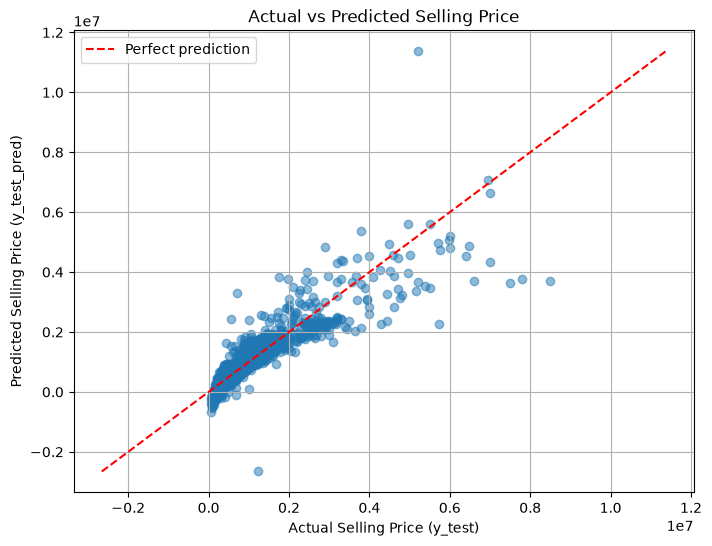

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)

# Perfect prediction reference line
min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], "r--", label="Perfect prediction")

plt.xlabel("Actual Selling Price (y_test)")
plt.ylabel("Predicted Selling Price (y_test_pred)")
plt.title("Actual vs Predicted Selling Price")
plt.legend()
plt.grid(True)
plt.show()

### Linear Regression Conclusion:

Linear Regression achieved an MAE of approximately ₹169,007, RMSE of ₹345,792, and R² of 0.8033.
The model explains about 80.3% of the variation in used-car selling prices and provides a strong baseline for comparison with more advanced models. The higher RMSE compared with MAE suggests that some cars have relatively large prediction errors.

## Model 2: Ridge Regression

The following cells perform 5-fold cross-validation on the training data to select the Ridge regularization strength (alpha) with the lowest mean validation MAE.

In [15]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_sets = []

for fold_number, (train_indices, validation_indices) in enumerate(
    kf.split(X_train), start=1
):
    X_fold_train = X_train.iloc[train_indices]
    X_fold_validation = X_train.iloc[validation_indices]
    y_fold_train = y_train.iloc[train_indices]
    y_fold_validation = y_train.iloc[validation_indices]

    fold_sets.append({
        "fold": fold_number,
        "X_train": X_fold_train,
        "X_validation": X_fold_validation,
        "y_train": y_fold_train,
        "y_validation": y_fold_validation
    })

    print(
        f"Fold {fold_number}: "
        f"{len(X_fold_train)} training samples, "
        f"{len(X_fold_validation)} validation samples"
    )

Fold 1: 9756 training samples, 2439 validation samples
Fold 2: 9756 training samples, 2439 validation samples
Fold 3: 9756 training samples, 2439 validation samples
Fold 4: 9756 training samples, 2439 validation samples
Fold 5: 9756 training samples, 2439 validation samples


In [16]:
from sklearn.base import clone
from sklearn.linear_model import Ridge

alpha_values = [0.01, 0.1, 1, 10, 100]
cv_results = {}

for alpha in alpha_values:
    fold_mae = []

    for fold_data in fold_sets:
        X_fold_train = fold_data["X_train"]
        X_fold_validation = fold_data["X_validation"]
        y_fold_train = fold_data["y_train"]
        y_fold_validation = fold_data["y_validation"]

        # Fit preprocessing only on the current fold's training data
        fold_preprocessor = clone(preprocessor)
        X_fold_train_processed = fold_preprocessor.fit_transform(X_fold_train)
        X_fold_validation_processed = fold_preprocessor.transform(
            X_fold_validation
        )

        # Train and evaluate Ridge regression
        ridge_model = Ridge(alpha=alpha)
        ridge_model.fit(X_fold_train_processed, y_fold_train)

        y_fold_pred = ridge_model.predict(X_fold_validation_processed)
        fold_mae_value = mean_absolute_error(y_fold_validation, y_fold_pred)
        fold_mae.append(fold_mae_value)

        
    mean_mae = np.mean(fold_mae)
    cv_results[alpha] = mean_mae

    print(f"Alpha = {alpha}, Mean MAE: {mean_mae:.2f}")
 


Alpha = 0.01, Mean MAE: 181357.90
Alpha = 0.1, Mean MAE: 181751.60
Alpha = 1, Mean MAE: 189618.11
Alpha = 10, Mean MAE: 211924.27
Alpha = 100, Mean MAE: 225442.89


For alpha = 0.01 , the MAE is the least so I will choose the final value of alpha as 0.01 

In [17]:


RidgeModel = Ridge(alpha=0.01)
RidgeModel.fit(X_train_preprocessed, y_train)
y_test_ridgepred = RidgeModel.predict(X_test_preprocessed)

In [18]:
mae_ridge = mean_absolute_error(y_test, y_test_ridgepred)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_ridgepred))
r2_ridge = r2_score(y_test, y_test_ridgepred)

print(f"Ridge MAE: {mae_ridge:.2f}")
print(f"Ridge RMSE: {rmse_ridge:.2f}")
print(f"Ridge R² Score: {r2_ridge:.4f}")

Ridge MAE: 169025.50
Ridge RMSE: 345744.99
Ridge R² Score: 0.8034


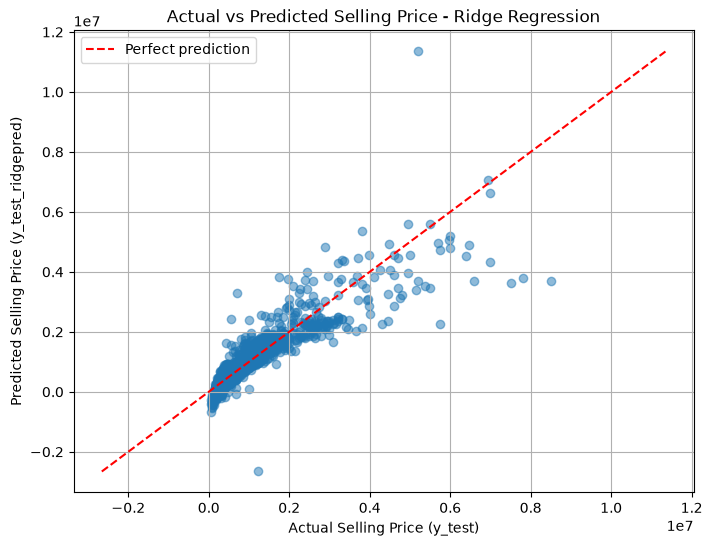

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_ridgepred, alpha=0.5)

min_value = min(y_test.min(), y_test_ridgepred.min())
max_value = max(y_test.max(), y_test_ridgepred.max())
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual Selling Price (y_test)")
plt.ylabel("Predicted Selling Price (y_test_ridgepred)")
plt.title("Actual vs Predicted Selling Price - Ridge Regression")
plt.legend()
plt.grid(True)
plt.show()

### Ridge Regression Conclusion:

The tuned Ridge Regression model (alpha = 0.01) achieved performance very similar to the Linear Regression baseline.
Linear Regression: MAE ≈ ₹,169,007, RMSE ≈ ₹3,45,792, R² ≈ 0.8033
Ridge Regression: MAE ≈ ₹1,69,026, RMSE ≈ ₹3,45,745, R² ≈ 0.8034

Ridge slightly improved RMSE and R², while Linear Regression had a slightly lower MAE. Overall, the differences are negligible, suggesting that L2 regularization did not significantly improve performance on this dataset.

## Model 3: Decision Tree Regresson

In [20]:
from sklearn.tree import DecisionTreeRegressor

DT1 = DecisionTreeRegressor(random_state=42) # random state will make sure that the same tree is reproduced everytime
DT1.fit(X_train_preprocessed, y_train)

y_test_DT1pred = DT1.predict(X_test_preprocessed)

In [ ]:
#Evaluation of the decision tree regressor model
mae_DT1 = mean_absolute_error(y_test, y_test_DT1pred)
rmse_DT1 = np.sqrt(mean_squared_error(y_test, y_test_DT1pred))
r2_DT1 = r2_score(y_test, y_test_DT1pred)

print(f"Decision Tree MAE: {mae_DT1:.2f}")
print(f"Decision Tree RMSE: {rmse_DT1:.2f}")
print(f"Decision Tree R² Score: {r2_DT1:.4f}")

Decision Tree MAE: 128271.52
Decision Tree RMSE: 336715.01
Decision Tree R² Score: 0.8135


In [21]:
#Checking if the model is overfitting by comparing training vs testing errors
y_train_DT1pred = DT1.predict(X_train_preprocessed)

mae_DT1_train = mean_absolute_error(y_train, y_train_DT1pred)
rmse_DT1_train = np.sqrt(mean_squared_error(y_train, y_train_DT1pred))
r2_DT1_train = r2_score(y_train, y_train_DT1pred)

print(f"Decision Tree MAE: {mae_DT1_train:.2f}")
print(f"Decision Tree RMSE: {rmse_DT1_train:.2f}")
print(f"Decision Tree R² Score: {r2_DT1_train:.4f}")

Decision Tree MAE: 4799.00
Decision Tree RMSE: 19681.92
Decision Tree R² Score: 0.9995


The error on test set appears to be much higher than the error on training set which clearly indicates overfitting

Now I will tune the decision tree regressor model with the help of some hyperparameters and see if it helps in reducing overfitting and making the predictions more accurate

In [50]:
#hyperparameters

# splitting is allowed till these are not violated
max_depth = [5,10, 12, 15, 20, 25, 30, 35]  # Maxium depth that the tree can reach
min_samples_to_split = [2, 5, 10, 12, 15, 20, 25, 30, 35, 40]   # Minimum number of samples that a node must have in order for it further split  
min_samples_in_child_nodes = [1, 2, 3, 4] # Minimum number of samples that must be present in each of the child nodes after splitting

# Total combinations of all 3 hyperparameters to try from = 8 x 8 x 4 = 256


In [51]:
all_dt_results = []
best_params = None
best_mae = float("inf")

for depth in max_depth:
    for min_split in min_samples_to_split:
        for min_leaf in min_samples_in_child_nodes:
            fold_mae = []

            for fold_data in fold_sets:
                X_fold_train = fold_data["X_train"]
                X_fold_validation = fold_data["X_validation"]
                y_fold_train = fold_data["y_train"]
                y_fold_validation = fold_data["y_validation"]

                # Fit preprocessing only on the current fold's training data
                fold_preprocessor = clone(preprocessor)
                X_train_fold_processed = fold_preprocessor.fit_transform(
                    X_fold_train
                )
                X_validation_fold_processed = fold_preprocessor.transform(
                    X_fold_validation
                )

                model = DecisionTreeRegressor(
                    max_depth=depth,
                    min_samples_split=min_split,
                    min_samples_leaf=min_leaf,
                    random_state=42
                )

                model.fit(X_train_fold_processed, y_fold_train)
                predictions = model.predict(X_validation_fold_processed)

                fold_mae.append(
                    mean_absolute_error(y_fold_validation, predictions)
                )

            mean_cv_mae = np.mean(fold_mae)

            result = {
                "max_depth": depth,
                "min_samples_split": min_split,
                "min_samples_leaf": min_leaf,
                "mean_mae": mean_cv_mae
            }
            all_dt_results.append(result)

            if mean_cv_mae < best_mae:
                best_mae = mean_cv_mae
                best_params = {
                    "max_depth": depth,
                    "min_samples_split": min_split,
                    "min_samples_leaf": min_leaf
                }

print("Best parameters:", best_params)
print(f"Lowest mean CV MAE: {best_mae:.2f}")

Best parameters: {'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1}
Lowest mean CV MAE: 118443.63


After tuning the model , it turns out that max_depth : 12, min_samples_split: 2, min_samples_leaf: 1 are the best possible values for the hyperparameters 

In [52]:
# Training the model with hyperparams on the training set

DT1tuned = DecisionTreeRegressor(max_depth=12 ,min_samples_split= 2, min_samples_leaf=1, random_state=42)
DT1tuned.fit(X_train_preprocessed,y_train)
DT1tuned_pred = DT1tuned.predict(X_test_preprocessed) 


In [ ]:
#Evaluating the tuned Decision Tree on test set

mae_DT1tuned = mean_absolute_error(y_test, DT1tuned_pred)
rmse_DT1tuned = np.sqrt(mean_squared_error(y_test, DT1tuned_pred))
r2_DT1tuned = r2_score(y_test, DT1tuned_pred)

print(f"Tuned Decision Tree MAE: {mae_DT1tuned:.2f}")
print(f"Tuned Decision Tree RMSE: {rmse_DT1tuned:.2f}")
print(f"Tuned Decision Tree R² Score: {r2_DT1tuned:.4f}")

Tuned Decision Tree MAE: 115542.46
Tuned Decision Tree RMSE: 308722.99
Tuned Decision Tree R² Score: 0.8432


In [56]:
#Evalutaing the tuned Decision Tree on training data to see how tuning has affected overfitting

y_train_DT1tuned_pred = DT1tuned.predict(X_train_preprocessed)

mae_DT1_train = mean_absolute_error(y_train, y_train_DT1tuned_pred )
rmse_DT1_train = np.sqrt(mean_squared_error(y_train, y_train_DT1tuned_pred ))
r2_DT1_train = r2_score(y_train, y_train_DT1tuned_pred )

print(f"Decision Tree MAE: {mae_DT1_train:.2f}")
print(f"Decision Tree RMSE: {rmse_DT1_train:.2f}")
print(f"Decision Tree R² Score: {r2_DT1_train:.4f}")

Decision Tree MAE: 68231.24
Decision Tree RMSE: 118689.05
Decision Tree R² Score: 0.9834


### Decision Tree Regression Conclusion

The initial Decision Tree heavily overfit the training data, achieving a training R² of 0.9995 but a test R² of only 0.8135.

After tuning the tree using 5-fold cross-validation, the selected hyperparameters were `max_depth=12`, `min_samples_split=2`, and `min_samples_leaf=1`.

The tuned model achieved:
- MAE: ₹1,15,542
- RMSE: ₹3,08,722
- R²: 0.8432

Although some overfitting still remains, restricting the tree significantly improved its generalization and test performance. The tuned Decision Tree also outperformed both Linear Regression and Ridge Regression.